In [13]:
using CairoMakie, JLD2, Base64

using LinearAlgebra, StaticArrays, Interpolations, Statistics, Random, Distributions
using SpatiotemporalGPs
using ForwardDiff

include(joinpath(@__DIR__, "../", "color-scheme", "julia", "Fieldline.jl"))
using .Fieldline

SRC_DIR = joinpath(@__DIR__, "../", "src")

include(joinpath(SRC_DIR, "jordan_lake_domain.jl"))
include(joinpath(SRC_DIR, "kf.jl"))
include(joinpath(SRC_DIR, "ngpkf.jl"))
include(joinpath(SRC_DIR, "SyntheticData.jl"))
include(joinpath(SRC_DIR, "ergodic.jl"))
include(joinpath(SRC_DIR, "variograms.jl"))
include(joinpath(SRC_DIR, "SOC_Controller.jl"))
include(joinpath(SRC_DIR, "simulator_spatial.jl"))
include(joinpath(SRC_DIR, "simulator_ST.jl"))
include(joinpath(SRC_DIR, "Convex_bound_avoidance.jl"))
include(joinpath(SRC_DIR, "transects.jl"))



┌ Warning: Replacing docs for `Main.Variograms.hp_fit :: Tuple{Any}` in module `Main.Variograms`
└ @ Base.Docs docs/Docs.jl:243


Main.Transects

# Synthetic Windfield Information

In [43]:
seeds = 1234:(1234 + 30 - 1)

aggregate_synthetic_data = Vector{Array{Float64, 3}}()

Δt      = 2.5              # seconds
dt_min  = Δt / 60          # minutes
dt_hrs  = Δt / 3600        # hours
T_begin = 9.0               # hours
T_end   = 12.0              # hours
ts_hrs  = T_begin:dt_hrs:T_end
ts_min  = T_begin*60:dt_min:T_end*60

σt, σs = 1.0, 1.0
lt = 0.75 * 60.0
ls = 0.75
kt = Matern(1/2, σt, lt)
ks = Matern(1/2, σs, ls)

dx = 0.05
xs = 0:dx:1.6
ys = 0:dx:1.9
grid_pts = vec([@SVector[x, y] for x in xs, y in ys])

for seed in seeds
    Random.seed!(seed)
    push!(aggregate_synthetic_data, STGPKF.generate_spatiotemporal_process(xs, ys, dt_min, (T_end - T_begin) * 60, ks, kt).data)
end

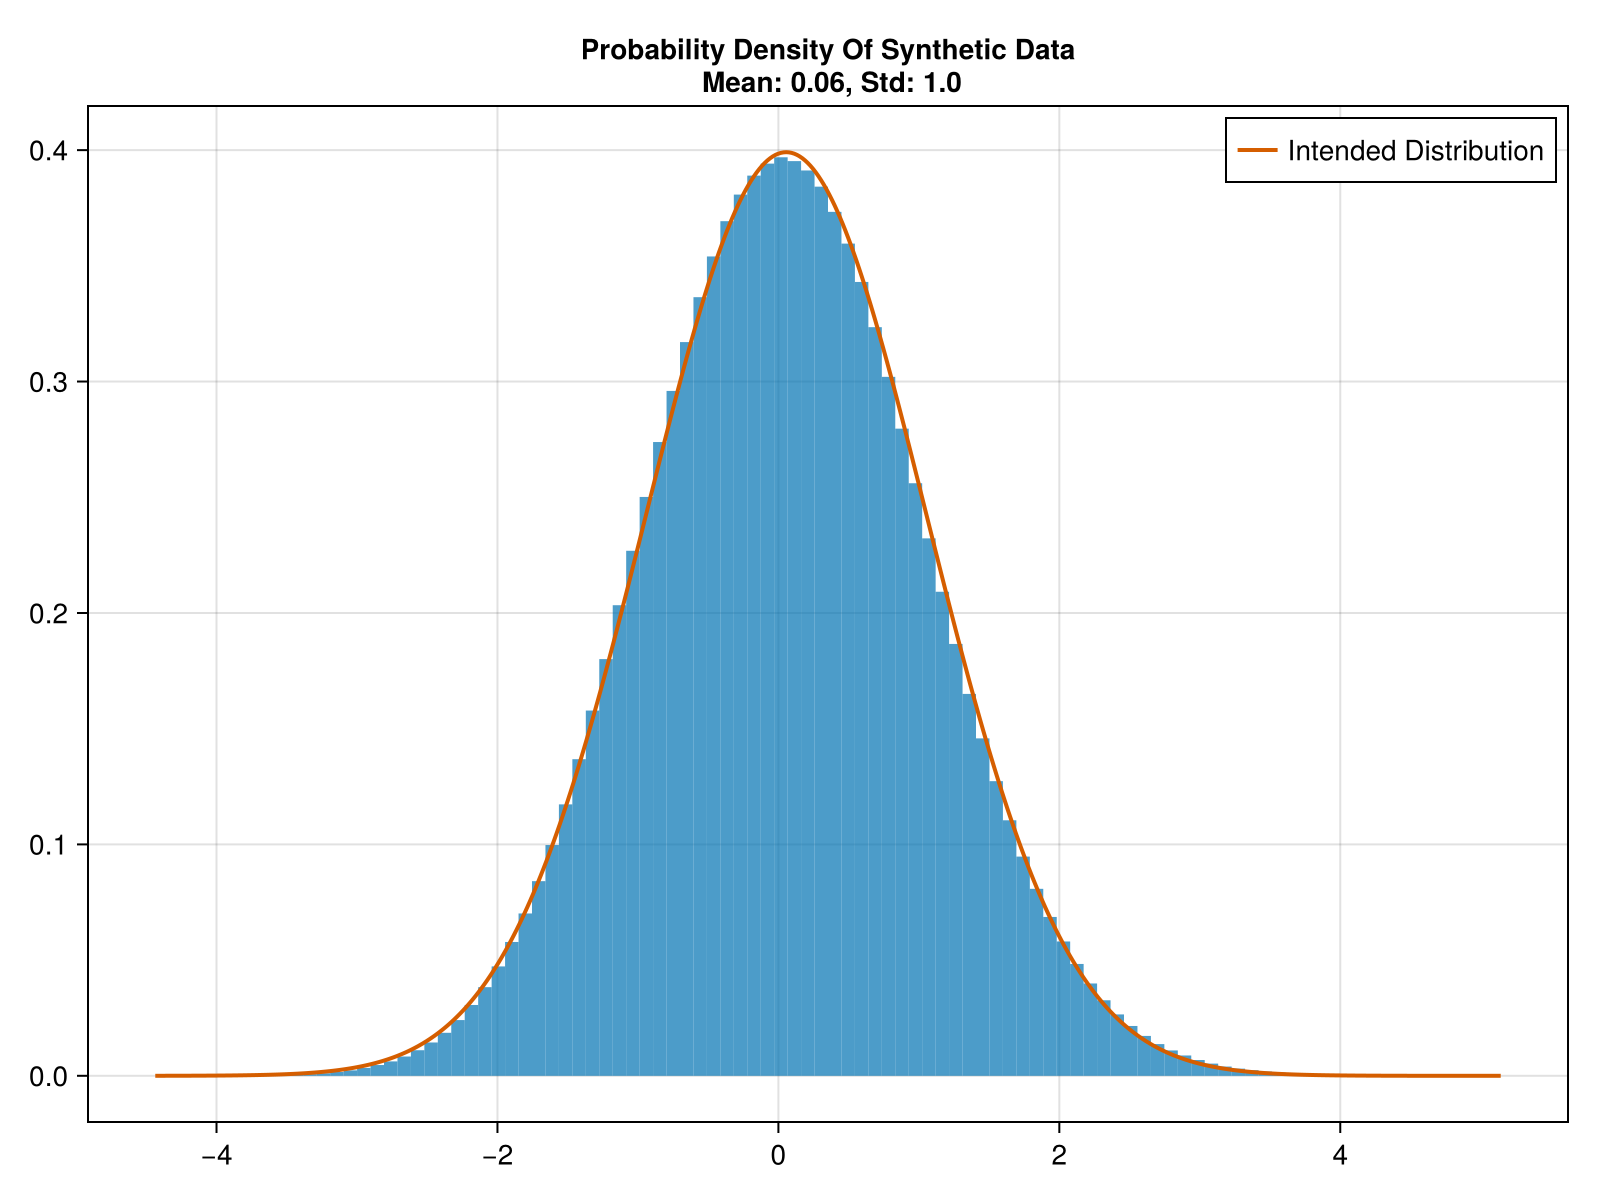

In [44]:
fig = Figure(size = (800, 600))
axis = Axis(fig[1, 1])

# 1. Properly flatten all 3D arrays into a single 1D Float64 vector
data_flat = reduce(vcat, vec.(aggregate_synthetic_data))

# 2. Plot Histogram
hist!(
    axis, 
    data_flat, 
    bins = 100, 
    color = Fieldline.categorical(1), 
    alpha = 0.7, 
    normalization = :pdf
)

# 3. Fit Gaussian curve
x_grid = range(minimum(data_flat), maximum(data_flat), length=500)
gaussian_pdf = pdf.(Normal(mean(data_flat), std(data_flat)), x_grid)

lines!(
    axis, 
    x_grid, 
    gaussian_pdf, 
    color = Fieldline.categorical(2), 
    linewidth = 2, 
    label = "Intended Distribution"
)

# 4. Set Title
axis.title = titlecase("probability density of synthetic data\n Mean: $(round(mean(data_flat), digits=2)), Std: $(round(std(data_flat), digits=2))")

# Add Legend
axislegend(axis)

save("results_mc/synthetic_data_histogram.png", fig)

fig

In [ ]:
================================================================================
MONTE CARLO SIMULATION SUMMARY REPORT
================================================================================
Execution Timestamp: 2026-08-10 08:40:24
Total Wall Runtime:  8331.11 seconds
Number of MC Seeds:  30 (Base Seed: 1234)
Target Reference Value: 2.0
================================================================================

Strategy: transect
  - Global Spatial RMSE:             0.878202 ± 0.018101
  - Target-Masked RMSE:              1.593650 ± 0.047590
  - Ground-Truth Weighted RMSE:      0.875769 ± 0.022405
  - Mean Clarity Deficit:            0.000000
  - Final Clarity Deficit:           0.000000
  - Error Mean:                      -1.944808
  - Error Std Dev:                   1.119016
  - Proportion In Range (±1.0):      0.1991 (19.91%)

Strategy: ergo_nonadaptive
  - Global Spatial RMSE:             0.875123 ± 0.012700
  - Target-Masked RMSE:              1.559071 ± 0.047081
  - Ground-Truth Weighted RMSE:      0.862131 ± 0.016872
  - Mean Clarity Deficit:            0.178688
  - Final Clarity Deficit:           0.176277
  - Error Mean:                      -1.944995
  - Error Std Dev:                   1.095822
  - Proportion In Range (±1.0):      0.1784 (17.84%)

Strategy: ergo_adaptive
  - Global Spatial RMSE:             0.878629 ± 0.011977
  - Target-Masked RMSE:              1.611659 ± 0.040695
  - Ground-Truth Weighted RMSE:      0.872095 ± 0.020161
  - Mean Clarity Deficit:            0.007632
  - Final Clarity Deficit:           0.006063
  - Error Mean:                      -1.759740
  - Error Std Dev:                   1.168564
  - Proportion In Range (±1.0):      0.2529 (25.29%)

Strategy: bb_ipp
  - Global Spatial RMSE:             0.900532 ± 0.016926
  - Target-Masked RMSE:              1.684823 ± 0.037420
  - Ground-Truth Weighted RMSE:      0.917457 ± 0.021186
  - Mean Clarity Deficit:            0.008201
  - Final Clarity Deficit:           0.004317
  - Error Mean:                      -1.851737
  - Error Std Dev:                   1.151878
  - Proportion In Range (±1.0):      0.2164 (21.64%)

